<a href="https://colab.research.google.com/github/HanifFaishalH/PCVK25_3F_15/blob/master/Week9_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install pytesseract

In [ ]:
import cv2 as cv
import numpy as np
import pytesseract
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

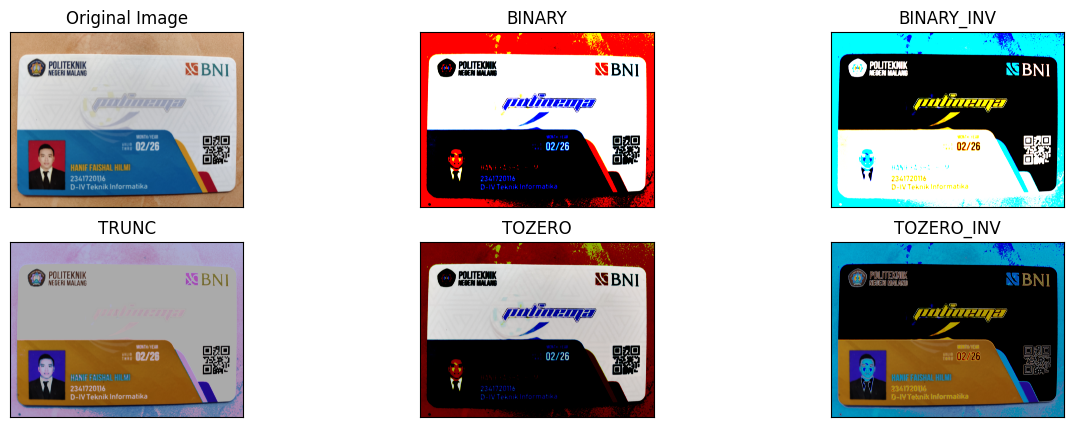

In [ ]:
filename = ('/content/drive/MyDrive/PCVK25_3F_15/TI-3F_TugasKelompok3/KTMNew.jpg')
img = cv.cvtColor(cv.imread(filename), cv.COLOR_BGR2RGB)
thresh1 = cv.imread(filename)
thresh2 = cv.imread(filename)
thresh3 = cv.imread(filename)
thresh4 = cv.imread(filename)
thresh5 = cv.imread(filename)
thresh = 170 # nilai threshold yang ditentukan

# === Global Threshold ===

#1. thresh1 jika pixel di img>127, maka thresh1 bernilai 1(putih) selain itu bernilai 0(hitam)
thresh1[img>thresh] = 255
thresh1[img<=thresh] = 0

#2. thresh2 adalah binary threshold inverse
thresh2 = 255 - thresh1

#3. Threshold truncate
thresh3[img>thresh] = thresh

#4. Threshold to zero
thresh4[img<thresh] = 0

#5. Threshold to zero inverse
thresh5[img>thresh] = 0

titles = ['Original Image','BINARY','BINARY_INV','TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize=(15,5))
for i in range(6):
    plt.subplot(2,3,i+1), plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

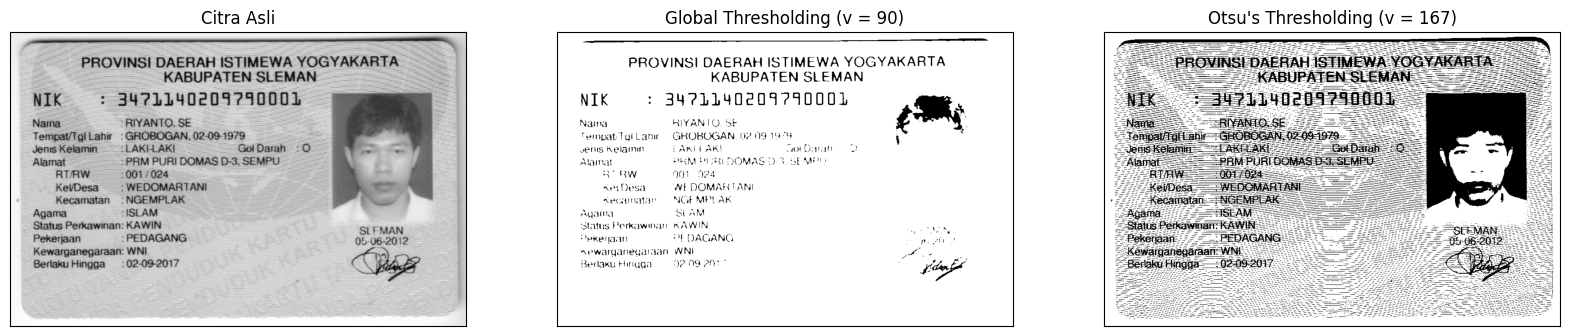

In [ ]:
# Otsu Thresholding
filename = '/content/drive/MyDrive/PCVK25_3F_15/image/ktp_riyanto.png'
img = cv.imread(filename, 0)
blur = cv.GaussianBlur(img, (5, 5), 0)

def otsu(gray):
    pixel_number = gray.shape[0] * gray.shape[1]
    mean_weight = 1.0 / pixel_number
    his, bins = np.histogram(gray, np.arange(0, 257))
    final_thresh = 1
    final_value = -1
    intensity_arr = np.arange(256)

    for t in bins[1:-1]:
        pcb = np.sum(his[:int(t)])
        pcf = np.sum(his[int(t):])
        if pcb == 0 or pcf == 0:
            continue
        Wb = pcb * mean_weight
        Wf = pcf * mean_weight
        mub = np.sum(intensity_arr[:int(t)] * his[:int(t)]) / float(pcb)
        muf = np.sum(intensity_arr[int(t):] * his[int(t):]) / float(pcf)
        value = Wb * Wf * (mub - muf) ** 2
        if value > final_value:
            final_thresh = t
            final_value = value

    final_img = gray.copy()
    final_img[gray > final_thresh] = 255
    final_img[gray <= final_thresh] = 0
    return final_img, final_thresh

# Jalankan fungsi Otsu
otsu_biner, otsu_thresh = otsu(img)
x = "Otsu's Thresholding (v = " + str(otsu_thresh) + ")"

# Global Thresholding
ret, th1 = cv.threshold(blur, 90, 225, cv.THRESH_BINARY)

titles = ['Citra Asli', 'Global Thresholding (v = 90)', x]
citra3 = [blur, th1, otsu_biner]

plt.figure(figsize=(20, 15))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(citra3[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()


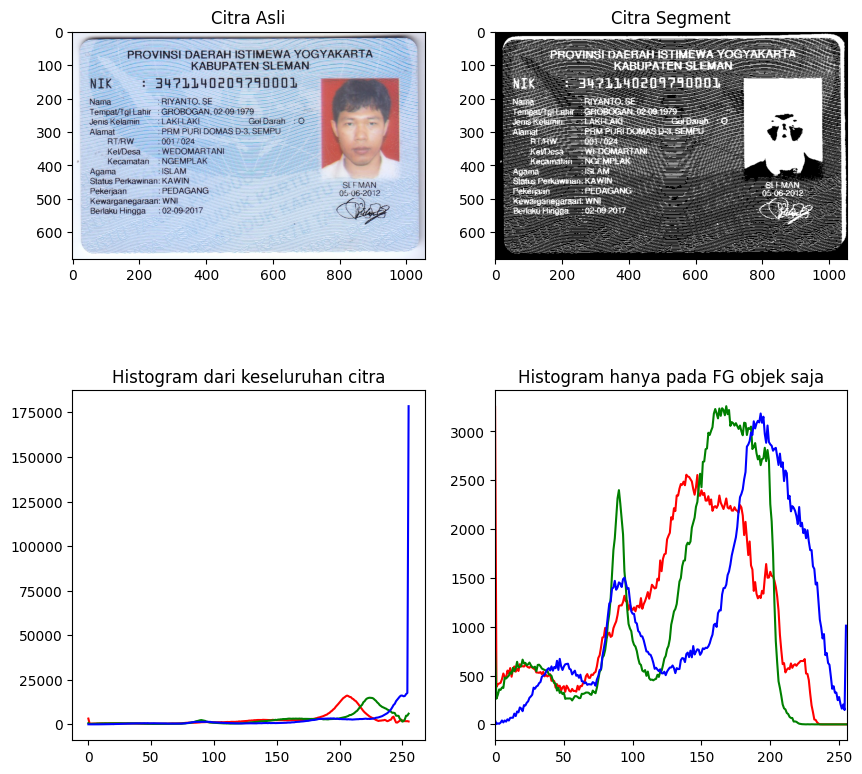

In [ ]:
# histogram dari citra yang tersegmentasi
filename = '/content/drive/MyDrive/PCVK25_3F_15/image/ktp_riyanto.png'
img = cv.imread(filename)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

ret3, mask = cv.threshold(img_gray, 200, 255, cv.THRESH_BINARY_INV)

plt.figure(figsize=(10, 10))
plt.subplot(2,2,1),plt.imshow(img)
plt.title('Citra Asli')
plt.subplot(2,2,2),plt.imshow(mask, 'gray')
plt.title('Citra Segment')
color = ('r','g','b')

for i, col in enumerate(color):
  hist0 = cv.calcHist([img], [i], None, [256], [0,256])
  plt.subplot(2,2,3), plt.plot(hist0, color = col)
  plt.title('Histogram dari keseluruhan citra')
  hist1 = cv.calcHist([img], [i], mask, [256], [0,256])
  plt.subplot(2,2,4), plt.plot(hist1, color = col)
  plt.title('Histogram hanya pada FG objek saja')
  plt.xlim([0,256])
plt.show()

(<Axes: >, <matplotlib.image.AxesImage at 0x78784468b590>)

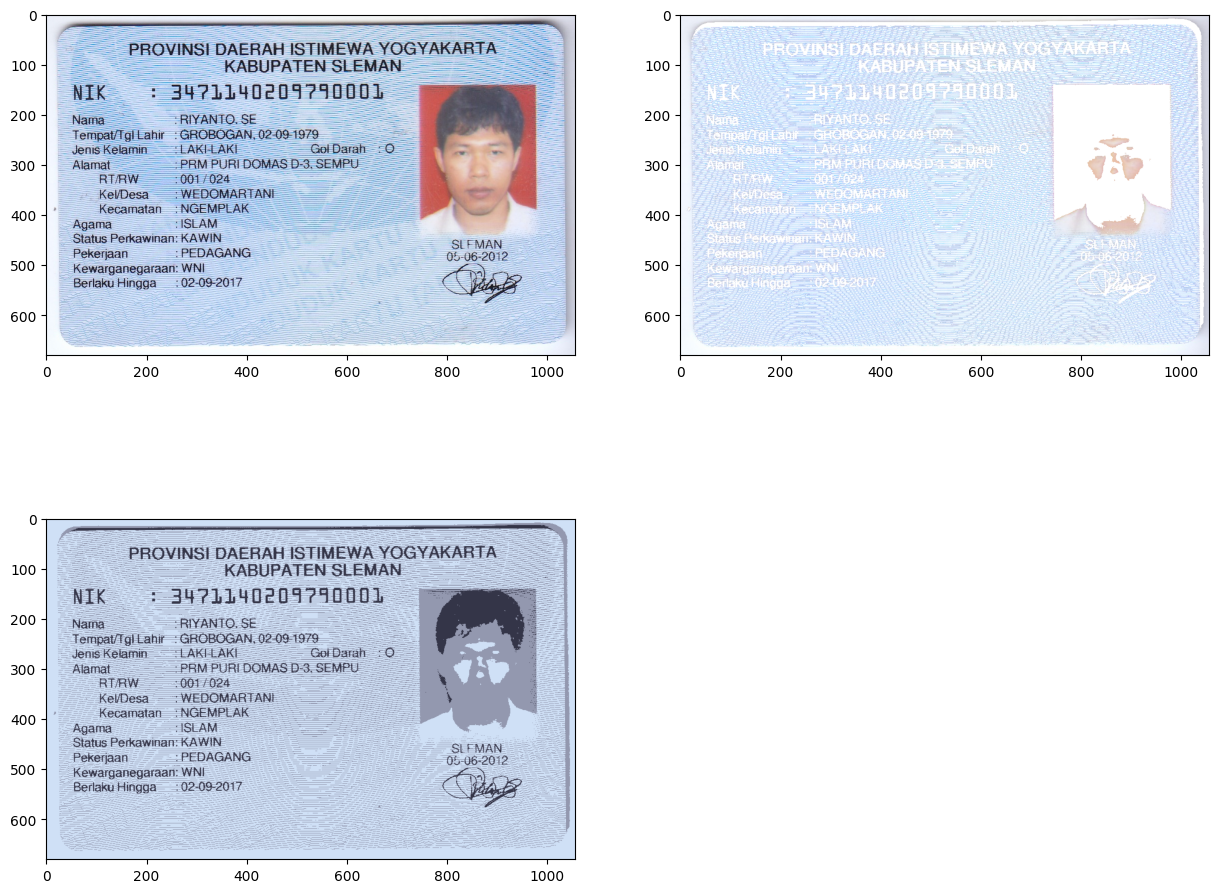

In [ ]:
# === Segementasi warna pada citra KTP Riyanto hanya warna biru saja menggunakan K-Means ===
filename = '/content/drive/MyDrive/PCVK25_3F_15/image/ktp_riyanto.png'
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# reshape array ke 2D
pixel_values = img.reshape((-1,3))
# konversi ke float
pixel_values = np.float32(pixel_values)

criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 150, 0.1)
k = 3
_, labels, (centers) = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

# konversi titik centroid ke integer
centers = np.uint8(centers)

# flattening label array
labels = labels.flatten()

# konversi warna pixel asli ke warna tiap centoridnya
segmented_image = centers[labels.flatten()]

# reshape ke bentu image asli
segmented_image = segmented_image.reshape(img.shape)
masked_image = np.copy(img)
masked_image0 = masked_image.reshape((-1,3))
masked_image0[labels != 1] = [255,255,255]
masked_image0 = masked_image0.reshape(img.shape)

plt.figure(figsize=(15,12))
plt.subplot(2,2,1),plt.imshow(img)
plt.subplot(2,2,2),plt.imshow(masked_image0)
plt.subplot(2,2,3),plt.imshow(segmented_image)

In [ ]:
!sudo apt-get install tesseract-ocr-ind

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr-ind is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [ ]:
def display(img,cmap='gray'):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img,cmap='gray')

In [ ]:
# Menambahkan kotak untuk mendeteksi teks pada gambar
from pytesseract import Output
img = cv.imread('/content/drive/MyDrive/PCVK25_3F_15/image/ktp_riyanto.png')
d = pytesseract.image_to_data(img, output_type=Output.DICT)
print(d.keys())


dict_keys(['level', 'page_num', 'block_num', 'par_num', 'line_num', 'word_num', 'left', 'top', 'width', 'height', 'conf', 'text'])


em

PROVINSI DAERAH ISTIMEWA YOGYAKARTA
KABUPATEN SLEMAN

 

NIK : 34711140209790001

Nama :RIYANTO. SE

Tempat/Tgl Lahir : GROBOGAN. 02-09-1979

Jenis Kelamin : LAKI-LAKI Gol Darah : 0

Alamat PRM PURI DOMAS D-3. SEMPU
RTRW 1001 1024

Kel/Desa : WEDOMARTANI!
Kecamatan : NGEMPLAK

Agama "ISLAM
Status Bean KAWIN SLEMAN
Pekerjaan : PEDAGANG 05-06-2012

Kewarganegaraan: WNI HI —
Berlaku Hingga :02-09-2017 NIA

   
 

 



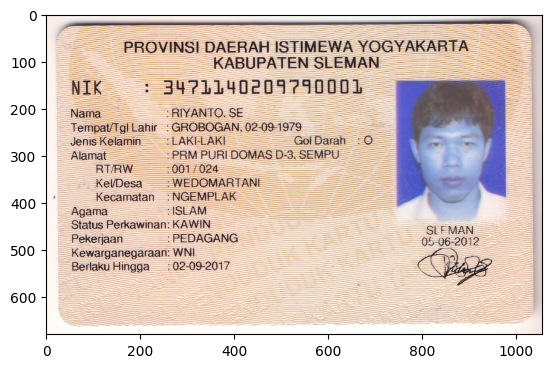

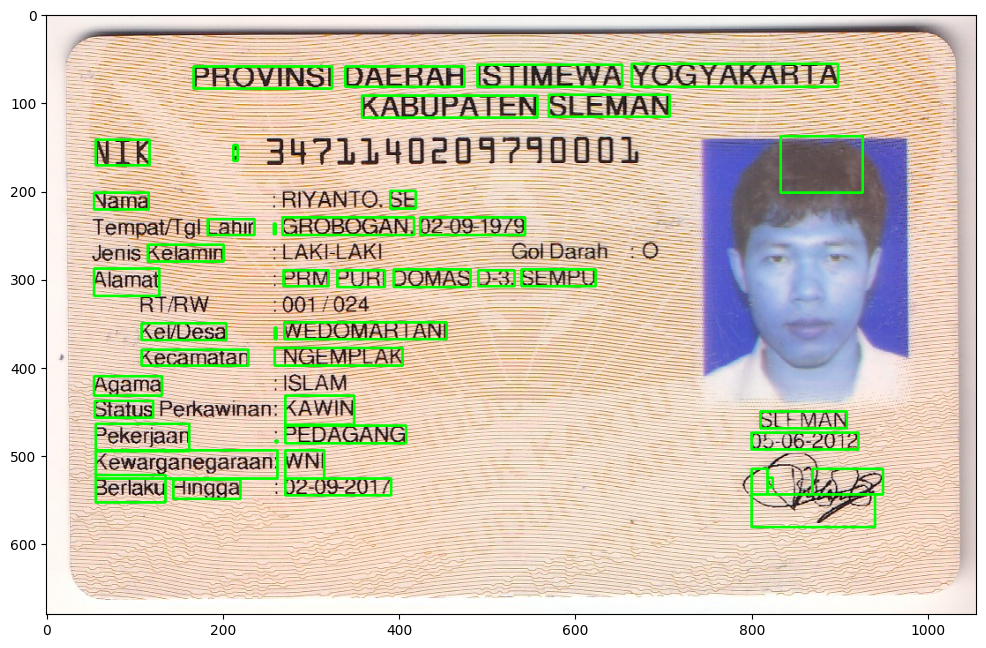

In [ ]:
plt.imshow(img)

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
th, threshed = cv.threshold(gray, 127, 255, cv.THRESH_TRUNC)
text1 = pytesseract.image_to_data(threshed,output_type='data.frame')
text2 = pytesseract.image_to_string(threshed, lang="ind")

n_boxes = len(text1['text'])
for i in range(n_boxes):
    if int(text1['conf'][i]) > 60:
        (x, y, w, h) = (text1['left'][i], text1['top'][i], text1['width'][i], text1['height'][i])
        img = cv.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
display(img)

print(text2)
text = text1[text1.conf != -1]
lines = text.groupby('block_num')['text'].apply(list)
conf = text.groupby(['block_num'])['conf'].mean()

### Tugas
Implementasi hasil citra yang telah diproses dengan global thresholding dan hasilnya diproses untuk membaca teks yang ada pada KTP

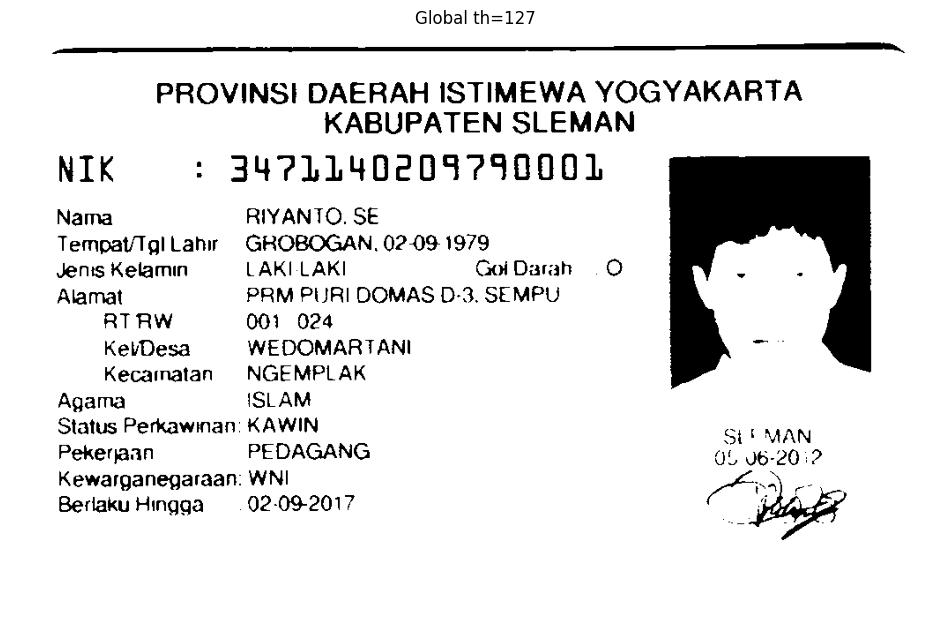

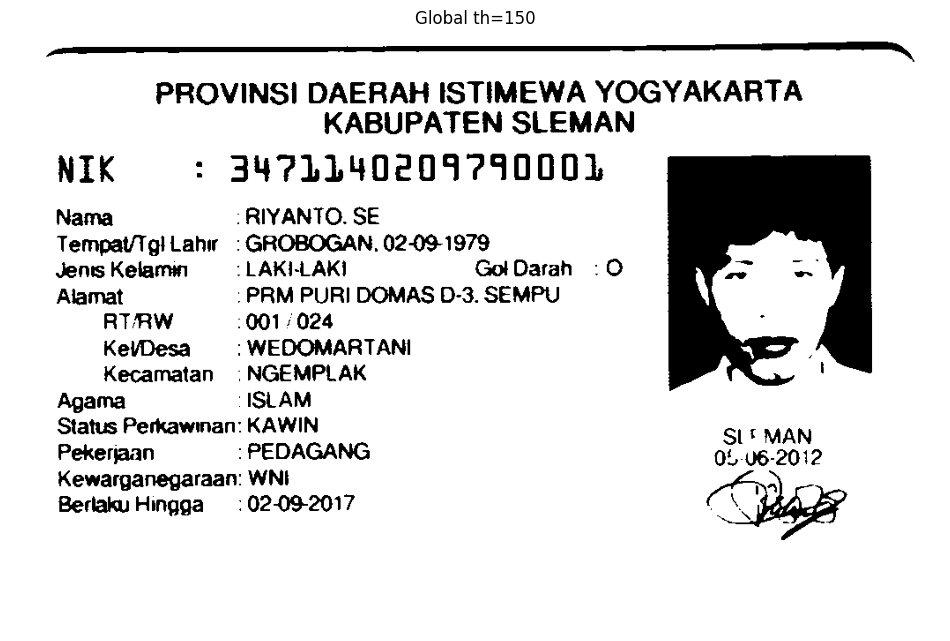

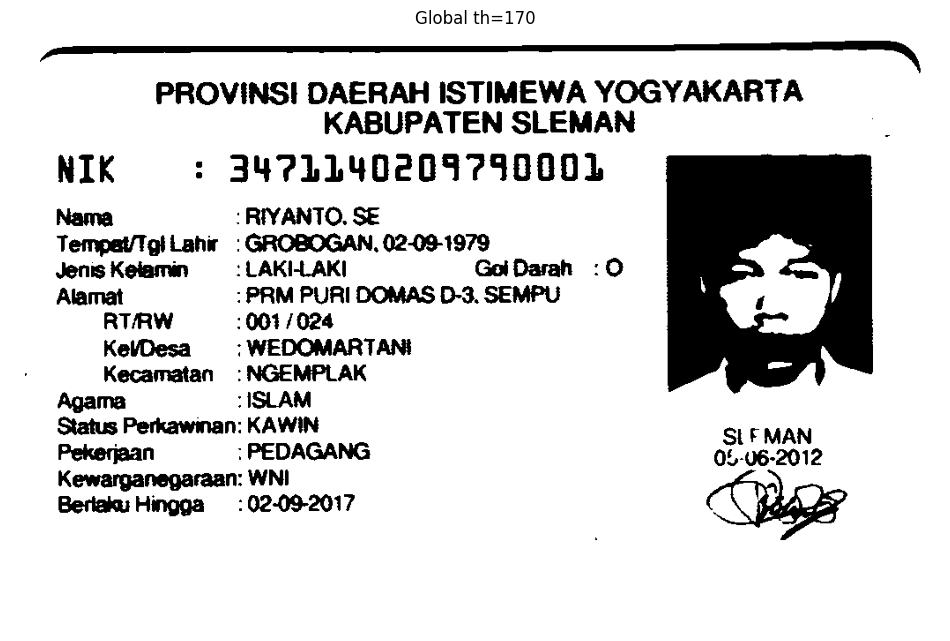

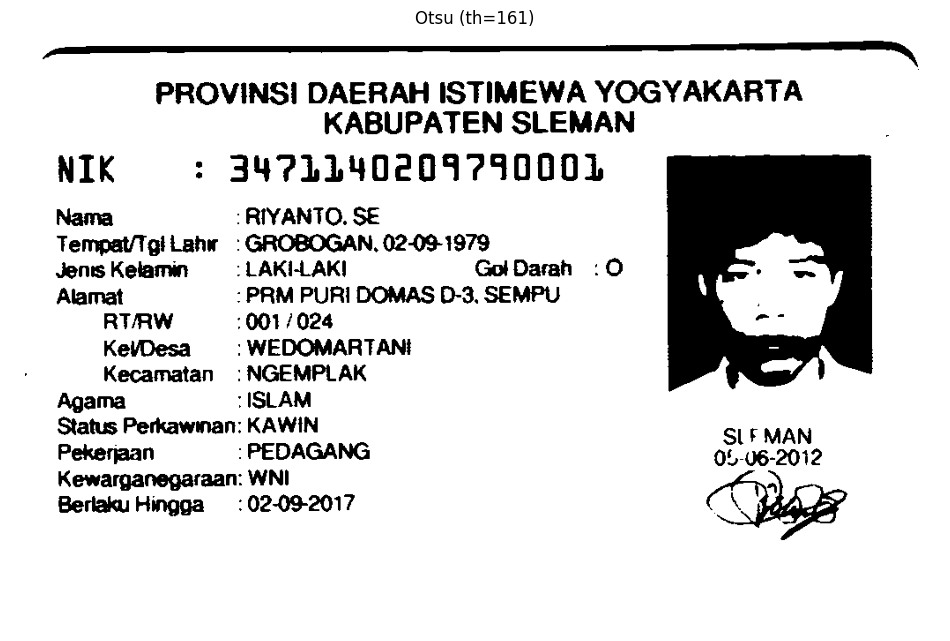

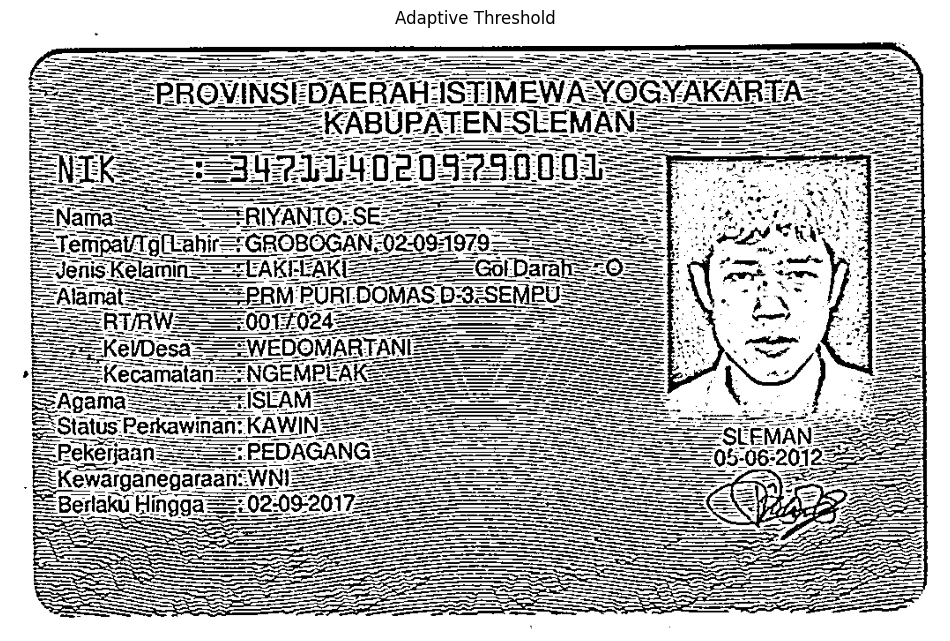

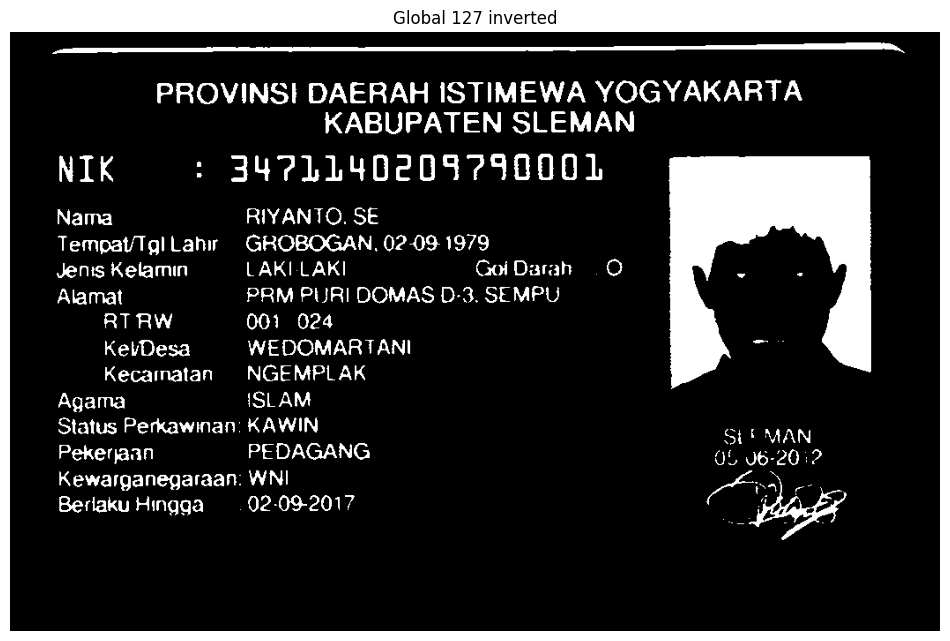


--- Hasil OCR: gray ---
NIK =: 34?1140209790001 J 
SSS SSS = 
= Kecamatan :NGEMPLAK == == Se 2a 

--- Hasil OCR: global 127 ---
———$ 
PROVINSI DAERAH ISTIMEWA YOGYAKARTA 
KABUPATEN SLEMAN 
NIK : 3471140209790001 
Nama RIYANTO. SE 
Tempat/Tgl Lahr GROBOGAN. 02-09 1979 
Jens Kelamin LAKI-LAKI Goi Darah 0 - - 
Alamat PRM PURI DOMAS D-3. SEMPU 
RT RW 001 024 
KelDesa WEDOMARTANI - 
Kecamatan NGEMPLAK 
Agama ISLAM 
Status Perkawinan: KAWIN sas 
Pekernjaan PEDAGANG on 620 
Kewarganegaraan: WNI e - 
Berlaku Hingga =: 0209-2017 Be 

--- Hasil OCR: global 170 ---
LT Kgow«Xvw«aerrr—r————rre\ 
PROVINS! DAERAH ISTIMEWA YOGYAKARTA 
KABUPATEN SLEMAN ; 
NIK : 3471140209790001 Nama :RIVANTO. SE Tempat/Tgi Lahr: GROBOGAN, 02-09-1979 : Jenis Kelamin —: LAKI-LAKI GoiDarah :O = Alamat -PRM PURI DOMAS D-3, SEMPU , = 
RTRW 001/024 
KevDesa : WEDOMARTANI 
: Kecamatan :NGEMPLAK com Agama HISLAM Status Perkawinan: KAWIN Pekerjaan : PEDAGANG crue aet2 Kewarganegaraan: WNI Berlaku Hingga 02-09-2017 Re 

--- Has

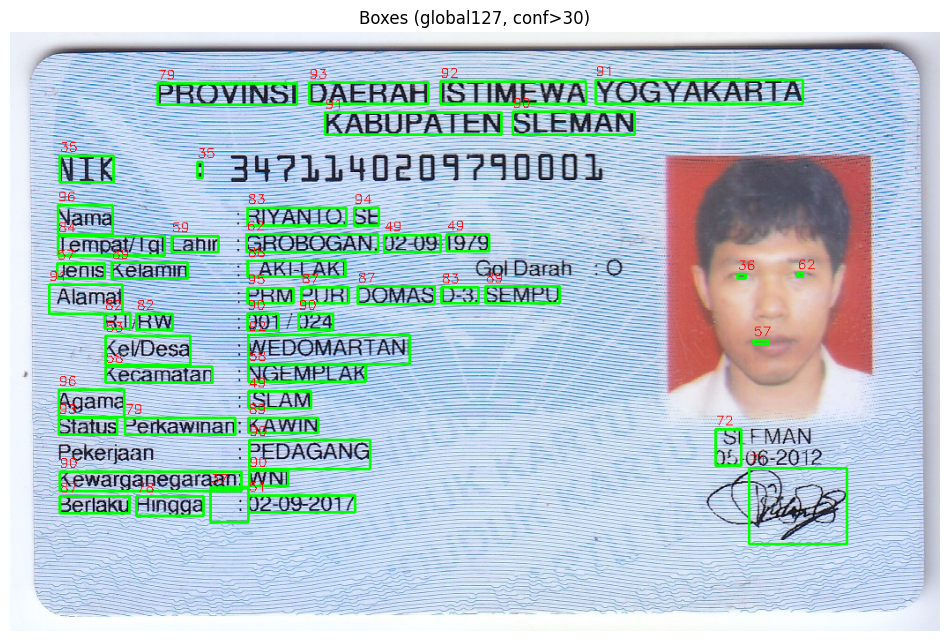

In [ ]:
filename = '/content/drive/MyDrive/PCVK25_3F_15/image/ktp_riyanto.png'
img = cv.imread(filename)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

def display(img, cmap='gray', title=None):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    if cmap is None:
        ax.imshow(img)
    else:
        ax.imshow(img, cmap=cmap)
    if title: plt.title(title)
    plt.axis('off')
    plt.show()

# === Mencoba berbagai segmentasi ===

# Citra gray
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Gaussian blur + global binary
blur = cv.GaussianBlur(gray, (5,5), 0)
_, th_global_150 = cv.threshold(blur, 150, 255, cv.THRESH_BINARY)
_, th_global_127 = cv.threshold(blur, 127, 255, cv.THRESH_BINARY)
_, th_global_170 = cv.threshold(blur, 170, 255, cv.THRESH_BINARY)
display(th_global_127, cmap='gray', title='Global th=127')
display(th_global_150, cmap='gray', title='Global th=150')
display(th_global_170, cmap='gray', title='Global th=170')

# Otsu
_, th_otsu = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
display(th_otsu, cmap='gray', title=f'Otsu (th={int(_ )})')

# Adaptive
th_adapt = cv.adaptiveThreshold(blur, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv.THRESH_BINARY, 11, 2)
display(th_adapt, cmap='gray', title='Adaptive Threshold')

# e) inverted versions
th_global_127_inv = cv.bitwise_not(th_global_127)
display(th_global_127_inv, cmap='gray', title='Global 127 inverted')

# 4. Fungsi bantu untuk run tesseract dan print sample hasil image_to_data
def test_ocr(img_for_ocr, desc):
    print(f"\n--- Hasil OCR: {desc} ---")
    config = '--oem 3 --psm 6'
    data = pytesseract.image_to_data(img_for_ocr, output_type=Output.DICT, config=config)

    n_boxes = len(data['text'])
    current_line = 1
    line_text = ""

    for i in range(n_boxes):
        word = data['text'][i].strip()
        conf = float(data['conf'][i])

        # Abaikan kata kosong atau dengan confidence rendah
        if word == "" or conf < 0:
            continue

        # Jika pindah ke baris baru, cetak baris sebelumnya
        if data['line_num'][i] != current_line:
            print(line_text)
            line_text = ""
            current_line = data['line_num'][i]

        line_text += word + " "

    # Cetak baris terakhir
    if line_text.strip() != "":
        print(line_text)


# Menjalankan test pada beberapa preprocessing
txt_gray = test_ocr(gray, "gray")
txt_g127 = test_ocr(th_global_127, "global 127")
txt_g170 = test_ocr(th_global_170, "global 170")
txt_otsu = test_ocr(th_otsu, "otsu")
txt_adapt = test_ocr(th_adapt, "adaptive")
txt_inv = test_ocr(th_global_127_inv, "global 127 inverted")

# Jalankan OCR pada hasil threshold terbaik (misalnya global 127)
config = '--oem 3 --psm 6'
data_dict = pytesseract.image_to_data(th_global_127, output_type=Output.DICT, config=config)

# Fungsi menggambar bounding box
def draw_boxes(img_rgb_in, data_dict, conf_thresh=30):
    img_draw = img_rgb_in.copy()
    n = len(data_dict['text'])
    for i in range(n):
        try:
            conf = float(data_dict['conf'][i])
        except:
            conf = -1
        if conf > conf_thresh and data_dict['text'][i].strip() != '':
            x = data_dict['left'][i]
            y = data_dict['top'][i]
            w = data_dict['width'][i]
            h = data_dict['height'][i]
            cv.rectangle(img_draw, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv.putText(img_draw, f"{int(conf)}", (x, y - 5),
                       cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    return img_draw

# Panggil fungsi dengan data_dict yang benar
img_boxes = draw_boxes(img, data_dict, conf_thresh=30)
display(img_boxes, cmap=None, title="Boxes (global127, conf>30)")